## Profiling of SPH

### Baseline benchmark

In [4]:
import sph

In [ ]:
import matplotlib.pyplot as plt

Ns = [200, 400, 600, 800, 1000, 2000] # amount of particles
ts_avg = []


for N in Ns:
    t = %timeit -o sph.main(N)
    ts_avg.append(t.average)


plt.title("Baseline benchmark of sph.py")
plt.plot(Ns, ts_avg, marker='o', label="lists")
plt.xlabel("Amount of particles")
plt.legend()
plt.grid(True)
plt.yscale("log")
plt.ylabel("Average runtime (s)")
plt.show()

### cProfile

In [ ]:
# cProfile of functions in sph.py
!python -m cProfile -s cumulative sph.py | awk 'NR==5 || /sph.py/'

#### SnakeViz visualizations of cProfile

In [1]:
# writes cProfile resutls to file (profile.stats)
!python -m cProfile -o profile.stats sph.py

In [4]:
!python -m snakeviz profile.stats --server

snakeviz web server started on 127.0.0.1:8080; enter Ctrl-C to exit
http://127.0.0.1:8080/snakeviz/%2FUsers%2Fisakf%2Fdev%2Fkth%2Fhpc%2Foptimizations-of-sph%2Fprofile.stats
^C


![Snakeviz Of Baseline](./images/snakeviz_baseline.png)

### Line Profiler

In [3]:
%load_ext line_profiler

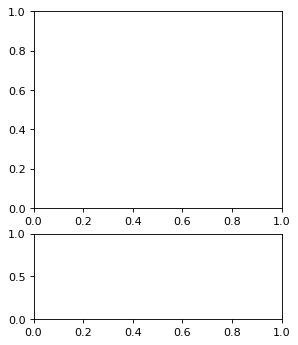

Timer unit: 1e-09 s

Total time: 0.76013 s
File: /home/isakf/dev/kth/optimizations-of-sph/sph.py
Function: W at line 13

Line #      Hits         Time  Per Hit   % Time  Line Contents
    13                                           def W(x, y, z, h):
    14                                               """
    15                                               Gausssian Smoothing kernel (3D)
    16                                                   x     is a vector/matrix of x positions
    17                                                   y     is a vector/matrix of y positions
    18                                                   z     is a vector/matrix of z positions
    19                                                   h     is the smoothing length
    20                                                   w     is the evaluated smoothing function
    21                                               """
    22                                           
    23       302  3696

In [ ]:
%lprun -f sph.W -f sph.gradW -f sph.getAcc -f sph.getDensity sph.main(1000)

### Memory Profiler